Заказчик этого исследования — Министерство культуры Российской Федерации. 
Нам нужно изучить рынок российского кинопроката и выявить текущие тренды. Уделите внимание фильмам, которые получили государственную поддержку. Ответить на вопрос, насколько такие фильмы интересны зрителю. 
Мы будем работать с данными, опубликованными на портале открытых данных Министерства культуры. Набор данных содержит информацию о прокатных удостоверениях, сборах и государственной поддержке фильмов, а также информацию с сайта КиноПоиск.

Описание данных

Таблица mkrf_movies содержит информацию из реестра прокатных удостоверений. У одного фильма может быть несколько прокатных удостоверений.

1) title — название фильма;
2) puNumber — номер прокатного удостоверения;
3) show_start_date — дата премьеры фильма;
4) type — тип фильма;
5) film_studio — студия-производитель;
6) production_country — страна-производитель;
7) director — режиссёр;
8) producer — продюсер;
9) age_restriction — возрастная категория;
10) refundable_support — объём возвратных средств государственной поддержки;
11) nonrefundable_support — объём невозвратных средств государственной поддержки;
12) financing_source — источник государственного финансирования;
13) budget — общий бюджет фильма;
14) ratings — рейтинг фильма на КиноПоиске;
15) genres — жанр фильма.

Таблица mkrf_shows содержит сведения о показах фильмов в российских кинотеатрах.

1) puNumber — номер прокатного удостоверения;
2) box_office — сборы в рублях.

In [ ]:
import pandas as pd
pd.set_option('display.float_format', '{:,.2f}'.format)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
try:
    data_movies= pd.read_csv('../data/mkrf_movies.csv')
except:
    data_movies= pd.read_csv('../data/mkrf_movies.csv')

In [ ]:
data_movies.head()

                  title   puNumber           show_start_date            type  \
0      Открытый простор  221048915  2015-11-27T12:00:00.000Z  Художественный   
1  Особо важное задание  111013716  2016-09-13T12:00:00.000Z  Художественный   
2          Особо опасен  221038416  2016-10-10T12:00:00.000Z  Художественный   
3          Особо опасен  221026916  2016-06-10T12:00:00.000Z  Художественный   
4          Особо опасен  221030815  2015-07-29T12:00:00.000Z  Художественный   

                                         film_studio production_country  \
0  Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...                США   
1                              Киностудия "Мосфильм"               СССР   
2  Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...                США   
3  Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...                США   
4  Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...                США   

            director                                           produ

Открываем 2ой датасет

In [ ]:
try:
    data_shows= pd.read_csv('../data/mkrf_shows.csv')
except:
    data_shows= pd.read_csv('../data/mkrf_shows.csv')

In [ ]:
data_shows.head()

    puNumber     box_office
0  111000113       2,450.00
1  111000115      61,040.00
2  111000116 153,030,013.40
3  111000117  12,260,956.00
4  111000118 163,684,057.79

In [ ]:
data_movies.info()
print()
data_shows.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7486 entries, 0 to 7485
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  7486 non-null   object 
 1   puNumber               7486 non-null   object 
 2   show_start_date        7486 non-null   object 
 3   type                   7486 non-null   object 
 4   film_studio            7468 non-null   object 
 5   production_country     7484 non-null   object 
 6   director               7477 non-null   object 
 7   producer               6918 non-null   object 
 8   age_restriction        7486 non-null   object 
 9   refundable_support     332 non-null    float64
 10  nonrefundable_support  332 non-null    float64
 11  budget                 332 non-null    float64
 12  financing_source       332 non-null    object 
 13  ratings                6519 non-null   object 
 14  genres                 6510 non-null   object 
dtypes: f

Объеденить таблицу можем по колонке puNumber, но их тип данных разный, в movies они имеют не целочисленный тип, нужно его изменить

In [ ]:
#При попытке сметить тип данных вылетает ошибка, связанно это с тем, что имеются строки, которые содержат нечисловые значения
#data_movies= data_movies['puNumber'].astype(int)
#data_movies.info()

Для возможности сменить тип данных применим метод str.isdigit(), чтоб выявить нечисловые строки

In [ ]:
data_movies[~data_movies['puNumber'].str.isdigit()]

                                  title    puNumber           show_start_date  \
804               Паранормальный Якутск   111004112  2012-08-24T12:00:00.000Z   
1797  Курбан-роман. (История с жертвой)         нет  2014-05-15T12:00:00.000Z   

                type       film_studio production_country    director  \
804   Художественный  ИП Тимофеев К.П.             Россия  К.Тимофеев   
1797  Художественный  ФОНД "ИННОВАЦИЯ"             Россия     С.Юзеев   

        producer                  age_restriction  refundable_support  \
804          NaN  «16+» - для детей старше 16 лет                 NaN   
1797  М.Галицкая  «12+» - для детей старше 12 лет                 NaN   

      nonrefundable_support  budget financing_source ratings genres  
804                     NaN     NaN              NaN     NaN    NaN  
1797                    NaN     NaN              NaN     NaN    NaN  

В 804 строке, скорее всего присутствует пробел, а в 1797 скорее всего пропуск.
Для удаления пробела используем метод стрим, а пропуск заменим на 0.

In [ ]:
data_movies.loc[804, 'puNumber'] = data_movies.loc[804, 'puNumber'].strip()
data_movies.loc[1797, 'puNumber'] = 0
data_movies['puNumber']=data_movies['puNumber'].astype(int)

In [ ]:
data_movies.info()
data_movies.count()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7486 entries, 0 to 7485
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  7486 non-null   object 
 1   puNumber               7486 non-null   int64  
 2   show_start_date        7486 non-null   object 
 3   type                   7486 non-null   object 
 4   film_studio            7468 non-null   object 
 5   production_country     7484 non-null   object 
 6   director               7477 non-null   object 
 7   producer               6918 non-null   object 
 8   age_restriction        7486 non-null   object 
 9   refundable_support     332 non-null    float64
 10  nonrefundable_support  332 non-null    float64
 11  budget                 332 non-null    float64
 12  financing_source       332 non-null    object 
 13  ratings                6519 non-null   object 
 14  genres                 6510 non-null   object 
dtypes: f

title                    7486
puNumber                 7486
show_start_date          7486
type                     7486
film_studio              7468
production_country       7484
director                 7477
producer                 6918
age_restriction          7486
refundable_support        332
nonrefundable_support     332
budget                    332
financing_source          332
ratings                  6519
genres                   6510
dtype: int64

Теперь puNumber имеет целочисленный тип. Теперь объеденим датафреймы и удалим shows

In [ ]:
data=data_movies.merge(data_shows, how='left')
del data_shows

In [ ]:
data.info()
data.count()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7486 entries, 0 to 7485
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  7486 non-null   object 
 1   puNumber               7486 non-null   int64  
 2   show_start_date        7486 non-null   object 
 3   type                   7486 non-null   object 
 4   film_studio            7468 non-null   object 
 5   production_country     7484 non-null   object 
 6   director               7477 non-null   object 
 7   producer               6918 non-null   object 
 8   age_restriction        7486 non-null   object 
 9   refundable_support     332 non-null    float64
 10  nonrefundable_support  332 non-null    float64
 11  budget                 332 non-null    float64
 12  financing_source       332 non-null    object 
 13  ratings                6519 non-null   object 
 14  genres                 6510 non-null   object 
 15  box_

title                    7486
puNumber                 7486
show_start_date          7486
type                     7486
film_studio              7468
production_country       7484
director                 7477
producer                 6918
age_restriction          7486
refundable_support        332
nonrefundable_support     332
budget                    332
financing_source          332
ratings                  6519
genres                   6510
box_office               3158
dtype: int64

Вывод:
1) После объединения датафреймов, в общем датафрейме стало 15 колонок, вместо 14, добавилась новая колонка "box_office@, состоящая из 3158 записей.

# 2. Предобработка данных

In [ ]:
data.head(50)

                                                title   puNumber  \
0                                    Открытый простор  221048915   
1                                Особо важное задание  111013716   
2                                        Особо опасен  221038416   
3                                        Особо опасен  221026916   
4                                        Особо опасен  221030815   
5                                   Остановился поезд  111013816   
6                                     Любовь и голуби  111007013   
7                                   Любовь и сигареты  221074614   
8                                  Отпетые мошенники.  121011416   
9                                 Отпуск за свой счет  111019114   
10  Превосходство Борна /По одноименной новелле Ро...  221031416   
11                                       Ответный ход  111019014   
12  Малышка на миллион /По мотивам рассказов Ф.Х.Т...  221011415   
13                                 Преданный сад

### Измение типов данных


In [ ]:
#Изменим тип данных для даты
data['show_start_date'] = pd.to_datetime(data['show_start_date'], format = '%Y-%m-%dT%H:%M:%S.%fZ')
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7486 entries, 0 to 7485
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   title                  7486 non-null   object        
 1   puNumber               7486 non-null   int64         
 2   show_start_date        7486 non-null   datetime64[ns]
 3   type                   7486 non-null   object        
 4   film_studio            7468 non-null   object        
 5   production_country     7484 non-null   object        
 6   director               7477 non-null   object        
 7   producer               6918 non-null   object        
 8   age_restriction        7486 non-null   object        
 9   refundable_support     332 non-null    float64       
 10  nonrefundable_support  332 non-null    float64       
 11  budget                 332 non-null    float64       
 12  financing_source       332 non-null    object        
 13  rat

In [ ]:
#Изменим тип данных ratings и приведем его к float, т.к значение можетт быть дробным
#data['ratings'].astype('float64')
data['ratings'].unique()

array(['7.2', '6.6', '6.8', '7.7', '8.3', '8.0', '7.8', '8.1', '7.1',
       '6.0', '7.4', '5.8', '8.7', '6.3', '6.9', '5.0', '4.3', '7.3',
       '7.0', '6.4', nan, '8.2', '7.5', '6.7', '7.9', '5.9', '6.2', '5.6',
       '6.5', '2.4', '7.6', '6.1', '8.6', '8.5', '8.8', '5.5', '5.1',
       '5.7', '5.4', '99%', '4.4', '4.5', '5.3', '4.1', '8.4', '2.6',
       '3.8', '4.6', '4.8', '4.0', '3.0', '1.6', '4.2', '5.2', '4.7',
       '4.9', '3.9', '2.7', '3.3', '2.9', '28%', '3.7', '1.4', '3.1',
       '97%', '3.5', '3.2', '2.8', '1.5', '2.1', '2.5', '9.2', '3.4',
       '1.1', '3.6', '83%', '64%', '91%', '94%', '62%', '79%', '90%',
       '19%', '88%', '1.0', '89%', '1.3', '1.9', '1.8', '1.2', '1.7',
       '9.0', '98%', '8.9', '9.1'], dtype=object)

In [ ]:
# Сразу заполним пустые значения, где они присутствуют, менять на медианное или среднее не стоит, лучше заменить его на 0, скорее всего фильм только вышел в прокат
data['ratings'] = data['ratings'].fillna(0)
data['ratings'] = data['ratings'].str.replace('%', '')
data['ratings'] = data['ratings'].astype('float64')
data['ratings'].unique()

array([ 7.2,  6.6,  6.8,  7.7,  8.3,  8. ,  7.8,  8.1,  7.1,  6. ,  7.4,
        5.8,  8.7,  6.3,  6.9,  5. ,  4.3,  7.3,  7. ,  6.4,  nan,  8.2,
        7.5,  6.7,  7.9,  5.9,  6.2,  5.6,  6.5,  2.4,  7.6,  6.1,  8.6,
        8.5,  8.8,  5.5,  5.1,  5.7,  5.4, 99. ,  4.4,  4.5,  5.3,  4.1,
        8.4,  2.6,  3.8,  4.6,  4.8,  4. ,  3. ,  1.6,  4.2,  5.2,  4.7,
        4.9,  3.9,  2.7,  3.3,  2.9, 28. ,  3.7,  1.4,  3.1, 97. ,  3.5,
        3.2,  2.8,  1.5,  2.1,  2.5,  9.2,  3.4,  1.1,  3.6, 83. , 64. ,
       91. , 94. , 62. , 79. , 90. , 19. , 88. ,  1. , 89. ,  1.3,  1.9,
        1.8,  1.2,  1.7,  9. , 98. ,  8.9,  9.1])

In [ ]:
data.loc[data['ratings'] > 18, 'ratings'] = data['ratings']/10
data['ratings'].unique()

array([7.2, 6.6, 6.8, 7.7, 8.3, 8. , 7.8, 8.1, 7.1, 6. , 7.4, 5.8, 8.7,
       6.3, 6.9, 5. , 4.3, 7.3, 7. , 6.4, nan, 8.2, 7.5, 6.7, 7.9, 5.9,
       6.2, 5.6, 6.5, 2.4, 7.6, 6.1, 8.6, 8.5, 8.8, 5.5, 5.1, 5.7, 5.4,
       9.9, 4.4, 4.5, 5.3, 4.1, 8.4, 2.6, 3.8, 4.6, 4.8, 4. , 3. , 1.6,
       4.2, 5.2, 4.7, 4.9, 3.9, 2.7, 3.3, 2.9, 2.8, 3.7, 1.4, 3.1, 9.7,
       3.5, 3.2, 1.5, 2.1, 2.5, 9.2, 3.4, 1.1, 3.6, 9.1, 9.4, 9. , 1.9,
       1. , 8.9, 1.3, 1.8, 1.2, 1.7, 9.8])

Вывод:
Мы выявели 2 колонки с несоответствием типов и заменили их.

### Выявелние и заполнение пропусков

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7486 entries, 0 to 7485
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   title                  7486 non-null   object        
 1   puNumber               7486 non-null   int64         
 2   show_start_date        7486 non-null   datetime64[ns]
 3   type                   7486 non-null   object        
 4   film_studio            7468 non-null   object        
 5   production_country     7484 non-null   object        
 6   director               7477 non-null   object        
 7   producer               6918 non-null   object        
 8   age_restriction        7486 non-null   object        
 9   refundable_support     332 non-null    float64       
 10  nonrefundable_support  332 non-null    float64       
 11  budget                 332 non-null    float64       
 12  financing_source       332 non-null    object        
 13  rat

In [ ]:
#Всего в датафрейме 7486 строк. Заполним данные в столбце film_studio
data['film_studio'] = data['film_studio'].fillna('Отсутствует студия')

In [ ]:
#Заполним данные в столбце production_country
data['production_country'] = data['production_country'].fillna('Страна не указана')

In [ ]:
#Заполним данные в столбце director
data['director'] = data['director'].fillna('Отсутствует директор')

In [ ]:
#Заполним данные в столбце producer
data['producer'] = data['producer'].fillna('Отсутствует продюсер')

In [ ]:
#data['refundable_support'].unique()
#Трогать пропуски не будет, т.к скорее всего они отсутствуют
data['refundable_support']=data['refundable_support']

In [ ]:
#Анологично поступим и с nonrefundable_support
data['nonrefundable_support']=data['nonrefundable_support']

In [ ]:
#data.financing_source.unique()
#В столбце заполнены те значения, которые поддерживают Министерством культуры, либо фондом кино, остальные скорее всего комерческие.
data['financing_source']=data['financing_source'].fillna('Комерческое финансирование')

In [ ]:
# В столбце бюджета заменим значение на 0, т.к скорее всего он отсутствует
data['budget']=data['budget'].fillna(0)

In [ ]:
# В столбце бюджета жанр, т.к скорее всего он отсутствует
data['genres']=data['genres'].fillna('Отсутствует жанр')

In [ ]:
#data['box_office'].unique()
#Пропуски в кассовых сборах заменим на 0
data['box_office']=data['box_office'].fillna(0)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7486 entries, 0 to 7485
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   title                  7486 non-null   object        
 1   puNumber               7486 non-null   int64         
 2   show_start_date        7486 non-null   datetime64[ns]
 3   type                   7486 non-null   object        
 4   film_studio            7486 non-null   object        
 5   production_country     7486 non-null   object        
 6   director               7486 non-null   object        
 7   producer               7486 non-null   object        
 8   age_restriction        7486 non-null   object        
 9   refundable_support     332 non-null    float64       
 10  nonrefundable_support  332 non-null    float64       
 11  budget                 7486 non-null   float64       
 12  financing_source       7486 non-null   object        
 13  rat

Вывод:
Теперь мы имеем полностью заполненный датафрейм, все пропущенные значения заполнены в каждом столбце, с таким датафреймом можно провести качественый исследовательский анализ.

### Изучение дубликатов

In [ ]:
#Проверим одинаковые строки строки.
data.duplicated().sum()

0

In [ ]:
#попробуем найти одинаковые значения по названию, дате, студии, страны, директора и продюссера
data[data.duplicated(subset=['title', 'show_start_date', 'film_studio', 'production_country', 'director', 'producer'], keep=False)]

                                  title   puNumber     show_start_date  \
1300                          Эпидемия_  121025713 2013-10-07 12:00:00   
1301                          Эпидемия_  221035513 2013-10-07 12:00:00   
1475                             Оторвы  121006514 2014-04-07 12:00:00   
1476                             Оторвы  221013214 2014-04-07 12:00:00   
2191                Последние пять лет.  221008115 2015-03-25 12:00:00   
2192                Последние пять лет.  121005715 2015-03-25 12:00:00   
2752  Пингвиненок Пороро: Большие гонки  224001915 2015-04-15 12:00:00   
2753  Пингвиненок Пороро: Большие гонки  124001915 2015-04-15 12:00:00   
3086                          Анархисты  221003916 2016-02-03 12:00:00   
3087                          Анархисты  121002316 2016-02-03 12:00:00   
4042                              Бугай  224021210 2010-09-24 12:00:00   
4043                              Бугай  124001210 2010-09-24 12:00:00   
6379                       Ян Антоныше

У нас имеются 8 одинаковых фильмов, все из них имеют разный номер проката, поэтому данные можно оставить, т.к они скроее всего использовались под разные цели.

In [ ]:
#Найдем строки с одинаковыми номерами прокатов, используем метод keep=Fasle, для возвращения булевой серии и с помощью метода loc найдем те строки где значения равно True.
data.loc[data['puNumber'].duplicated(keep=False)]

                                                  title   puNumber  \
4638                   Как жениться и остаться холостым  221154310   
4639  Иоанна - женщина на папском престоле /По роман...  221154310   
5067                                    Анализируй это!  221054410   
5068                                     Анализируй то!  221054410   

         show_start_date            type  \
4638 2010-12-17 12:00:00  Художественный   
4639 2010-12-17 12:00:00  Художественный   
5067 2010-05-25 12:00:00  Художественный   
5068 2010-05-25 12:00:00  Художественный   

                                            film_studio  \
4638  Ше Вам, Скрипт Ассосье, Тэ Фэ 1 Фильм Продюксь...   
4639   Константин Фильм, А Эр Ди Дегето Фильм, Дюне ...   
5067          Уорнер Бразерс, Вилладж Роудшоу Филмз ЛТД   
5068  Уорнер Бразерс, Виллидж Роадшоу Пикчерз, Эн-Пи...   

                                production_country        director  \
4638                                       Франция    Эрик Лар

In [ ]:
#data.loc[data['puNumber'] == 220000001]
#data.loc[data['puNumber'] == 220000002]
data['puNumber'].unique()
data.head()

                  title   puNumber     show_start_date            type  \
0      Открытый простор  221048915 2015-11-27 12:00:00  Художественный   
1  Особо важное задание  111013716 2016-09-13 12:00:00  Художественный   
2          Особо опасен  221038416 2016-10-10 12:00:00  Художественный   
3          Особо опасен  221026916 2016-06-10 12:00:00  Художественный   
4          Особо опасен  221030815 2015-07-29 12:00:00  Художественный   

                                         film_studio production_country  \
0  Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...                США   
1                              Киностудия "Мосфильм"               СССР   
2  Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...                США   
3  Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...                США   
4  Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...                США   

            director                                           producer  \
0      Кевин Костнер         

Мы имеет по 2 строки с повторяющимся номером проката, удалять строки не будем, а заменим их на свободные id

In [ ]:
data.loc[(data['puNumber'] == 221154310) & (data['title'] == 'Как жениться и остаться холостым'), 'puNumber'] = 220000001
data.loc[(data['puNumber'] == 221054410) & (data['title'] == 'Анализируй это!'), 'puNumber'] = 220000002

### Изучение категориальных данных

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7486 entries, 0 to 7485
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   title                  7486 non-null   object        
 1   puNumber               7486 non-null   int64         
 2   show_start_date        7486 non-null   datetime64[ns]
 3   type                   7486 non-null   object        
 4   film_studio            7486 non-null   object        
 5   production_country     7486 non-null   object        
 6   director               7486 non-null   object        
 7   producer               7486 non-null   object        
 8   age_restriction        7486 non-null   object        
 9   refundable_support     332 non-null    float64       
 10  nonrefundable_support  332 non-null    float64       
 11  budget                 7486 non-null   float64       
 12  financing_source       7486 non-null   object        
 13  rat

In [ ]:
#Изучим колонку с названием фильма
data['title'].unique()

array(['Открытый простор', 'Особо важное задание', 'Особо опасен', ...,
       'Щенячий патруль: Скорей спешим на помощь!',
       'Машины песенки. Серия "Испанские мотивы"',
       'Машины песенки. Серия "Когда цветут кактусы"'], dtype=object)

In [ ]:
data['type'].unique()

array(['Художественный', 'Анимационный', 'Прочие', 'Документальный',
       'Научно-популярный', ' Художественный', ' Анимационный',
       'Музыкально-развлекательный'], dtype=object)

In [ ]:
#Удалим лишние пробелы и переносы
data['type'] = data['type'].str.strip()
data['type'].unique()

array(['Художественный', 'Анимационный', 'Прочие', 'Документальный',
       'Научно-популярный', 'Музыкально-развлекательный'], dtype=object)

In [ ]:
#Повторим эту процедуру для каждого категориального столбца
data['production_country'] = data['production_country'].str.strip()
data['film_studio'] = data['film_studio'].str.strip()
data['director'] = data['director'].str.strip()
data['producer'] = data['producer'].str.strip()
data['age_restriction'] = data['age_restriction'].str.strip()
data['age_restriction'] = data['age_restriction'].str.strip()
data['financing_source'] = data['financing_source'].str.strip()
data['genres'] = data['genres'].str.strip()

In [ ]:
data.nunique()

title                    6772
puNumber                 7486
show_start_date          1965
type                        6
film_studio              5463
production_country        935
director                 4802
producer                 5335
age_restriction             5
refundable_support         34
nonrefundable_support      75
budget                    290
financing_source            4
ratings                    84
genres                    743
box_office               2938
dtype: int64

Вывод: 
1) проблема категориальных данных заключается в лишних пробелах, явчть категориальных значений была обработана в предыдущем шаге.
2) Такие столбцы, как: страна происхождения, режиссер, продюссер, жанр, содержат множественные значения строк, для этого в шаге 6 мы будем создавать новые столбцы, в которые войдут первые значения.

### Изучение количественных данных

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7486 entries, 0 to 7485
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   title                  7486 non-null   object        
 1   puNumber               7486 non-null   int64         
 2   show_start_date        7486 non-null   datetime64[ns]
 3   type                   7486 non-null   object        
 4   film_studio            7486 non-null   object        
 5   production_country     7486 non-null   object        
 6   director               7486 non-null   object        
 7   producer               7486 non-null   object        
 8   age_restriction        7486 non-null   object        
 9   refundable_support     332 non-null    float64       
 10  nonrefundable_support  332 non-null    float64       
 11  budget                 7486 non-null   float64       
 12  financing_source       7486 non-null   object        
 13  rat

In [ ]:
#Выведем статистические показатели фильмов, значния которых выше 0
quantitative_data = ['refundable_support' , 'nonrefundable_support', 'budget', 'box_office', 'ratings']
critical_data = data[data[quantitative_data]>0]
critical = data[data[quantitative_data]>0].describe()
critical

       puNumber  refundable_support  nonrefundable_support           budget  \
count      0.00              111.00                 323.00           315.00   
mean        NaN       35,486,486.49          50,345,784.25   134,096,082.35   
std         NaN       31,972,875.36          60,243,206.31   191,226,039.63   
min         NaN        3,500,000.00           3,000,000.00    14,462,464.00   
25%         NaN       15,000,000.00          25,000,000.00    46,153,866.50   
50%         NaN       25,000,000.00          30,000,000.00    73,379,554.00   
75%         NaN       50,000,000.00          45,000,000.00   150,004,286.50   
max         NaN      180,000,000.00         400,000,000.00 2,305,074,303.00   

       ratings       box_office  
count 6,519.00         3,134.00  
mean      6.49    77,064,365.82  
std       1.11   241,178,383.77  
min       1.00            40.00  
25%       5.90       101,028.75  
50%       6.60     2,409,099.35  
75%       7.20    24,569,794.87  
max       9.90 3

Проведем анализ колонки бюджет, т.к она имеет отношение к колонкам refundable_support и nonrefundable_support

In [ ]:
#Рассмотрим те фильмы, которые не окупили государственную поддержку
data[(data['refundable_support'] + data['nonrefundable_support']) > data['budget']]
low_budget = data[(data['refundable_support'] + data['nonrefundable_support']) > data['budget']]

Мы имеем 17 фильмов, которые получали господдержку, но в бюджете стоит 0, выясним объем в котором оказывалась гос поддержка.

In [ ]:
data['percent_of_support'] = (data['refundable_support'] + data['nonrefundable_support']) / data['budget']
data['percent_of_support'].median()

0.6140376284219444

То есть доля государственной поддержке в фильме по медианному показателю составляла ~60%.
По медиане можно заполнить пропущенные значения.

In [ ]:
percent = data['percent_of_support'].median()

In [ ]:
data.head()

                  title   puNumber     show_start_date            type  \
0      Открытый простор  221048915 2015-11-27 12:00:00  Художественный   
1  Особо важное задание  111013716 2016-09-13 12:00:00  Художественный   
2          Особо опасен  221038416 2016-10-10 12:00:00  Художественный   
3          Особо опасен  221026916 2016-06-10 12:00:00  Художественный   
4          Особо опасен  221030815 2015-07-29 12:00:00  Художественный   

                                         film_studio production_country  \
0  Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...                США   
1                              Киностудия "Мосфильм"               СССР   
2  Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...                США   
3  Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...                США   
4  Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...                США   

            director                                           producer  \
0      Кевин Костнер         

In [ ]:
#Заполним пропущенные значения
data.loc[low_budget.index, 'budget'] = ((data.loc[low_budget.index, 'refundable_support'] + data.loc[low_budget.index, 'nonrefundable_support']) / percent)
data.loc[low_budget.index].head()

                    title   puNumber     show_start_date            type  \
2053                  14+  111023614 2014-12-19 12:00:00  Художественный   
2058            Дуxless 2  111000415 2015-01-26 12:00:00  Художественный   
2472          Воин (2015)  111017315 2015-09-28 12:00:00  Художественный   
2532              Бармен.  111009615 2015-05-26 12:00:00  Художественный   
2615  Савва. Сердце воина  114001715 2015-07-21 12:00:00    Анимационный   

                                            film_studio production_country  \
2053                         ООО Киностудия  "Сентябрь"             Россия   
2058  ООО "Киностудия "Слово", ООО "Арт Пикчерс Студия"             Россия   
2472   ООО "Форпост Продакшн", ООО "Арт Пикчерс Студия"             Россия   
2532          АО "ВайТ Медиа", ООО "Арт Пикчерс Студия"             Россия   
2615   ООО "Глюкоза Продакшн", ООО "Арт Пикчерс Студия"             Россия   

          director                            producer  \
2053      А.Зайц

In [ ]:
critical

       puNumber  refundable_support  nonrefundable_support           budget  \
count      0.00              111.00                 323.00           315.00   
mean        NaN       35,486,486.49          50,345,784.25   134,096,082.35   
std         NaN       31,972,875.36          60,243,206.31   191,226,039.63   
min         NaN        3,500,000.00           3,000,000.00    14,462,464.00   
25%         NaN       15,000,000.00          25,000,000.00    46,153,866.50   
50%         NaN       25,000,000.00          30,000,000.00    73,379,554.00   
75%         NaN       50,000,000.00          45,000,000.00   150,004,286.50   
max         NaN      180,000,000.00         400,000,000.00 2,305,074,303.00   

       ratings       box_office  
count 6,519.00         3,134.00  
mean      6.49    77,064,365.82  
std       1.11   241,178,383.77  
min       1.00            40.00  
25%       5.90       101,028.75  
50%       6.60     2,409,099.35  
75%       7.20    24,569,794.87  
max       9.90 3

In [ ]:
critical.corr()

                       puNumber  refundable_support  nonrefundable_support  \
puNumber                    NaN                 NaN                    NaN   
refundable_support          NaN                1.00                   0.99   
nonrefundable_support       NaN                0.99                   1.00   
budget                      NaN                0.98                   1.00   
ratings                     NaN               -0.30                  -0.23   
box_office                  NaN                0.96                   0.99   

                       budget  ratings  box_office  
puNumber                  NaN      NaN         NaN  
refundable_support       0.98    -0.30        0.96  
nonrefundable_support    1.00    -0.23        0.99  
budget                   1.00    -0.19        1.00  
ratings                 -0.19     1.00       -0.16  
box_office               1.00    -0.16        1.00  

Отфильтровываются все значения равные 0, которых 96%.

Вывод:
1) Всего 4% фильмов имеют государственную поддержку, удалять критические значения не является разумным, так как все количественные значения прямопропорциональны, например, чем выше возвратны и невозвратные средства, тем выше бюджет и тем выше кассовые сборы, но при этом рейтинг показывает отрицательную динамику.

### Создание новых столбцов

In [ ]:
#Создадим колонку с информацией о годе проката
data['year_info'] = pd.DatetimeIndex(data['show_start_date']).year

In [ ]:
#При создание столбца для основного жанра и фио директора извлечем из строки первый элемент списка
data['director_name'] = data['director'].str.split(",").str[0]
data['main_genre'] = data['genres'].str.split(",").str[0]
#Затем удалим пробелы и переносы строк
data['director_initials'] = data['director_name'].str.strip()
data['main_genre'] = data['main_genre'].str.strip()

In [ ]:
#Проверим результат
data.head()

                  title   puNumber     show_start_date            type  \
0      Открытый простор  221048915 2015-11-27 12:00:00  Художественный   
1  Особо важное задание  111013716 2016-09-13 12:00:00  Художественный   
2          Особо опасен  221038416 2016-10-10 12:00:00  Художественный   
3          Особо опасен  221026916 2016-06-10 12:00:00  Художественный   
4          Особо опасен  221030815 2015-07-29 12:00:00  Художественный   

                                         film_studio production_country  \
0  Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...                США   
1                              Киностудия "Мосфильм"               СССР   
2  Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...                США   
3  Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...                США   
4  Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...                США   

            director                                           producer  \
0      Кевин Костнер         

In [ ]:
#Посчитаем долю государственной поддержки
data['support_share'] = (data['refundable_support'] + data['nonrefundable_support']) / data['budget']

In [ ]:
data.head()
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7486 entries, 0 to 7485
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   title                  7486 non-null   object        
 1   puNumber               7486 non-null   int64         
 2   show_start_date        7486 non-null   datetime64[ns]
 3   type                   7486 non-null   object        
 4   film_studio            7486 non-null   object        
 5   production_country     7486 non-null   object        
 6   director               7486 non-null   object        
 7   producer               7486 non-null   object        
 8   age_restriction        7486 non-null   object        
 9   refundable_support     332 non-null    float64       
 10  nonrefundable_support  332 non-null    float64       
 11  budget                 7486 non-null   float64       
 12  financing_source       7486 non-null   object        
 13  rat

Вывод: 
1) В данном пункте мы исправили проблему категориальных данных, присвоив новым колонкам их главный показатель.

Общий вывод:
1) В данном разделе мы провели первичный анализ данных:
    1. Изменили типы данных, там где это было необходимо
    2. Выявели и заменили пропущенные значения
    3. Изучили дубликаты и заменили значения номера прокатного удостоверения
    4. Изучили категориальные данные и выявили их основную проблему- слишком большое количество уникальных значений, из-за которых проводить анализ было бы невозможно
    5. Изучили количественные значения и выявили, что лишь 4% из всех фильмов имеют государственную поддержку
    6. Создали новые колонки для года, жанра и имени директора, тем самым извавившись от большое показателя уникальных значений.

# 3. Проводим исследовательский анализ данных

In [ ]:
#Сгруппипуем даныые и выясним сколько фильмов в прокате поступало каждый год
grouped_movie = data.query('box_office > 0').groupby('year_info')['box_office'].count()
grouped_movie = grouped_movie.to_frame().reset_index()
grouped_movie.rename(columns={'year_info':'year', 'box_office':'cinema_rental'}, inplace=True)
grouped_movie

   year  cinema_rental
0  2010            101
1  2011            109
2  2012            123
3  2013            179
4  2014            273
5  2015            462
6  2016            525
7  2017            357
8  2018            475
9  2019            530

In [ ]:
#Добавляем в срез новый столбец
movies_count = data.groupby('year_info')['title'].count()
movies_count = movies_count.to_frame().reset_index()
movies_count.rename(columns={'title':'total_movie'}, inplace=True)
movies_count['cinema_rental'] = grouped_movie['cinema_rental']
movies_count

   year_info  total_movie  cinema_rental
0       2010          985            101
1       2011          622            109
2       2012          593            123
3       2013          630            179
4       2014          807            273
5       2015          705            462
6       2016          818            525
7       2017          505            357
8       2018          891            475
9       2019          930            530

In [ ]:
movies_count['total_movie'].sum()

7486

In [ ]:
#Высчитываем долю фильмов показанных в кинотеатре
movies_count['movie_share'] = (movies_count['cinema_rental'] / movies_count['total_movie']) * 100
movies_count.rename(columns={'movie_share':'share'}, inplace=True)
display(movies_count)

   year_info  total_movie  cinema_rental  share
0       2010          985            101  10.25
1       2011          622            109  17.52
2       2012          593            123  20.74
3       2013          630            179  28.41
4       2014          807            273  33.83
5       2015          705            462  65.53
6       2016          818            525  64.18
7       2017          505            357  70.69
8       2018          891            475  53.31
9       2019          930            530  56.99

In [ ]:
#Высчитываем средние значения для фильмов, фильмов в кинотеатре и долю фильмов проката в кинотеатрах
print(movies_count['total_movie'].mean().round())
print(movies_count['cinema_rental'].mean().round())
print(movies_count['share'].mean())

749.0
313.0
42.146765469135865


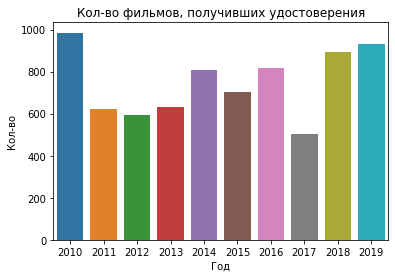

In [ ]:
#Строим график для фильмов, которые получили прокатные удостоверения
sns.barplot(x='year_info', y='total_movie', data=movies_count);
plt.title('Кол-во фильмов, получивших удостоверения');
plt.xlabel('Год');
plt.ylabel('Кол-во');

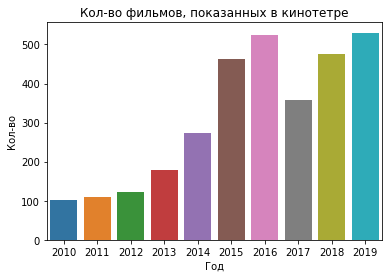

In [ ]:
#то же самое для фильмов, которые показывали в кинотеатре
sns.barplot(x='year_info', y='cinema_rental', data=movies_count);
plt.title('Кол-во фильмов, показанных в кинотетре');
plt.xlabel('Год');
plt.ylabel('Кол-во');

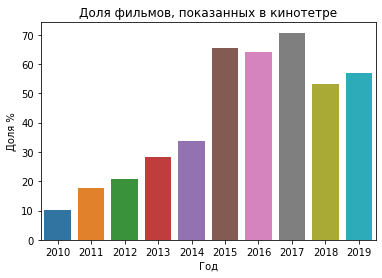

In [ ]:
#то же самое для фильмов, которые показывали в кинотеатре
sns.barplot(x='year_info', y='share', data=movies_count);
plt.title('Доля фильмов, показанных в кинотетре');
plt.xlabel('Год');
plt.ylabel('Доля %');

In [ ]:
movies_count.corr()

               year_info  total_movie  cinema_rental  share
year_info           1.00         0.16           0.91   0.87
total_movie         0.16         1.00           0.31  -0.06
cinema_rental       0.91         0.31           1.00   0.90
share               0.87        -0.06           0.90   1.00

Вывод 
1) С каждым годом растет количество фильмов, получивших прокатные удостоверения, хотя в 2017 произошел спад и со следующего года снова начало расти.
2) Описать динамику количства фильмов получивших удостоверение- тяжело, т.к показатели из года в год, то расли, то падали, тем неменее коэффицент корреляции имеет положительную динамику.
3) Количество фильмов, показанных в кинотеатре с каждым годом только расло и имеет лучшую положительную динамику среди 3 графиков.
4) Аналогичная ситуация и с долей фильмов, при этом в 2018 и 2019 году произошел спад, по сравнению с предыдущими годами, тем не менее динамика осталась положительной

### Изучаем динамику проката по годам

In [ ]:
box_office_result = data.groupby('year_info')['box_office'].agg('sum')
box_office_result = box_office_result/1000000

box_office_result

year_info
2010        2.43
2011       14.10
2012        6.96
2013       29.80
2014    7,444.95
2015   39,497.37
2016   47,866.30
2017   48,563.71
2018   49,668.40
2019   48,425.71
Name: box_office, dtype: float64

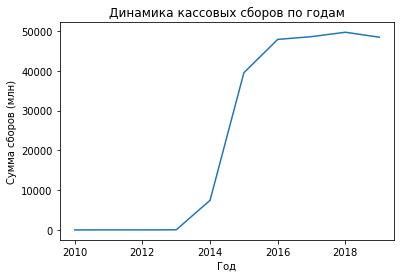

In [ ]:
plt.plot(box_office_result.index, box_office_result)
plt.xlabel('Год')
plt.ylabel('Сумма сборов (млн)')
plt.title('Динамика кассовых сборов по годам')
plt.show();

Вывод:
1) С 2010 по 2013 года отсутствует информация о прокатах, скорее всего, статистика в эти годы не велась и не учитывалась.
2) С 2013 по 2016 год произошел резкий подъем динамики кассовых сборов.
3) Наилучший показатель приходится на 2018, там сумма кассовых сборов ~50000 млн. рублей.

### Изучаем среднее и медианное значение сборов

In [ ]:
data.query('box_office > 0').groupby('year_info')['box_office'].agg(['median', 'mean',])

                median           mean
year_info                            
2010          1,710.00      24,046.08
2011          3,000.00     129,383.17
2012          6,220.00      56,548.15
2013          3,580.00     166,478.81
2014         20,400.00  27,270,885.93
2015      5,003,450.15  85,492,132.46
2016      3,915,041.02  91,173,904.27
2017      9,968,340.00 136,032,793.33
2018      8,891,102.21 104,565,059.23
2019      4,627,798.34  91,369,261.85

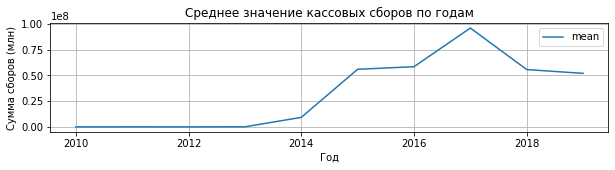

In [ ]:
#Cтроим график для средних показателей
data.groupby('year_info')['box_office'].agg(['mean']).plot(grid=True, figsize=(10,2))
plt.xlabel('Год')
plt.ylabel('Сумма сборов (млн)')
plt.title('Среднее значение кассовых сборов по годам')
plt.show();

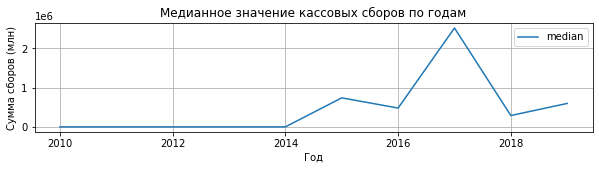

In [ ]:
#Cтроим график для средних показателей
data.groupby('year_info')['box_office'].agg(['median']).plot(grid=True, figsize=(10,2))
plt.xlabel('Год')
plt.ylabel('Сумма сборов (млн)')
plt.title('Медианное значение кассовых сборов по годам')
plt.show();

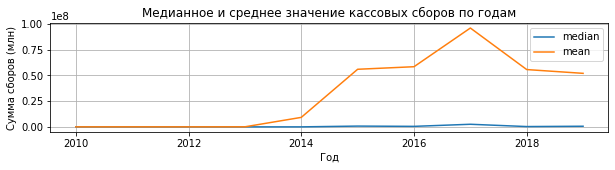

In [ ]:
#Сравниваем графики показателей
data.groupby('year_info')['box_office'].agg(['median', 'mean']).plot(grid=True, figsize=(10,2))
plt.xlabel('Год')
plt.ylabel('Сумма сборов (млн)')
plt.title('Медианное и среднее значение кассовых сборов по годам')
plt.show();

Вывод:
1) Среднее значение сильно отличается, от медианного. Связано это с тем, что имеются фильмы, кассовые сборы которых, сильно выше, чем у остальных.
2) По графику среднего сзначения можно сделать вывод, что в 2017 году был самый большой кассовый сбор, фильмы в этом году показали наилучший показатель.
3) Скорее всего такие высокие показатели, тюк вышли такие фильмы, как "Стражи галактики 2", что привлекло аудиторию детей и "Звездные войны: Последний джедай", что привлекло аудиторию взрослых.

### Изучаем влияние возрастных ограничений

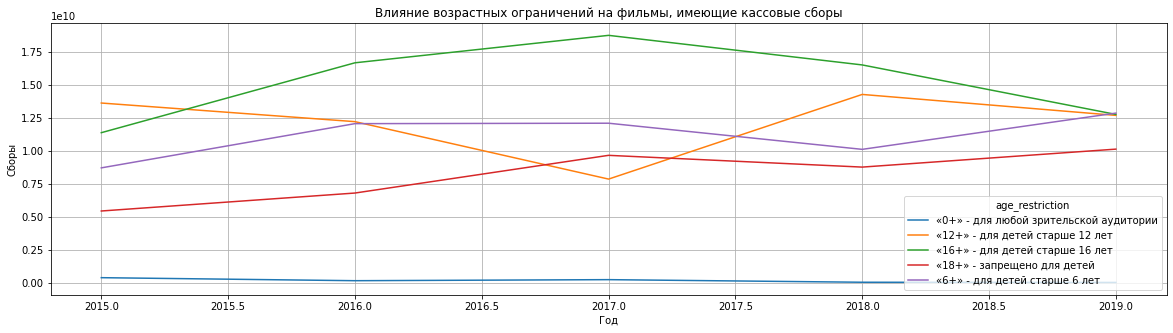

In [ ]:
data_age = data.query('box_office > 0 and year_info > 2014').pivot_table(index='year_info', columns='age_restriction', values='box_office', aggfunc='sum')
data_age.plot(kind='line', grid=True, figsize=(20,5))
plt.title('Влияние возрастных ограничений на фильмы, имеющие кассовые сборы')
plt.ylabel('Сборы')
plt.xlabel('Год')
plt.show()

In [ ]:
data_age.min().sort_values(ascending=False)

age_restriction
«16+» - для детей старше 16 лет          11,368,120,870.27
«6+» - для детей старше 6 лет             8,701,799,371.41
«12+» - для детей старше 12 лет           7,851,427,660.67
«18+» - запрещено для детей               5,432,308,367.44
«0+» - для любой зрительской аудитории       17,746,066.82
dtype: float64

In [ ]:
data_age.max().sort_values(ascending=False)

age_restriction
«16+» - для детей старше 16 лет          18,745,042,900.06
«12+» - для детей старше 12 лет          14,267,291,660.69
«6+» - для детей старше 6 лет            12,852,548,650.86
«18+» - запрещено для детей              10,121,796,303.64
«0+» - для любой зрительской аудитории      379,054,578.37
dtype: float64

Вывод:
1) Фильмы, которые пользуются самым маленьким спросом, относятся к катекогии 0+, в то время, как самые ходовые фильмы относятся к категории 16+.
2) В 2017 году фильмы в категории 16+ показали наилучший результат, почти 9 миллиардов, в то время, как фильмы категории 12+ показали худший результат в промежутке с 2015 по 2019 год, возможно показатель связан с отсутствием сказок и мультиков выпущенных в 2017 году.
3) Интересная тенденция в 2019 году, когда показатели 3 категорий (16+, 12+, 6+), показали относительно одинаковые результаты.
4) Если не брать в учет категорию 0+, то фильмы 18+ не пользуются популярностью, т.к ужасы не всем нравятся и основной контингент посещающих кинотеатр это подростки, дети и семьи.

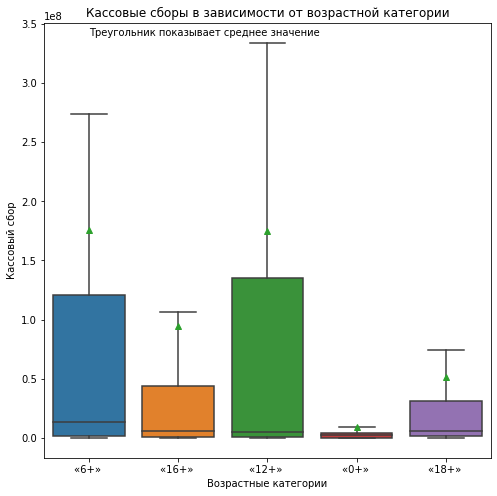

In [ ]:
import seaborn as sns
temp = data[data.box_office != 0].copy()
# для удобства укоротим названия категорий
def get_first_value(s, sep = ','):  # Функция для выбора первого элемента из перечисления
    value_lst = s.split(sep=sep)
    return value_lst[0]

temp['age_restriction'] = temp['age_restriction'].apply(lambda x: get_first_value(x, sep='-'))
# сохраним маску для среза по годам
year_mask = temp['year_info'] >= 2015

plt.figure(figsize=(8, 8))
(sns.boxplot(data = temp.loc[year_mask], y = 'box_office', x='age_restriction', showfliers=False, showmeans=True)
    .set(title = 'Кассовые сборы в зависимости от возрастной категории', 
         xlabel = 'Возрастные категории', ylabel = 'Кассовый сбор'))
plt.text(0, 3.4e8,'Треугольник показывает среднее значение')
plt.show()

Вывод по разделу:
    1) С каждым годом разтет количество фильмов, показанных в кинотеатре
    2) Общее количество фильмов в год всегда превышает 500 и не превышает 1000
    3) В среднем количество фильмов равно 749, в кинотеатре в среднем показывают 313, что составляет 42 %.
    4) С каждым годом растет количество фильмов, получивших прокатные удостоверения, наилучшим для проката годом в данной выборке можно считать 2018 год - сумма сборов практически дошла до 50 мрд. руб. Если не брать в расчет промежуток с 2010 по 2014 год, то минимальная сумма сборов была зафиксирована в 2015 году - 39 мрд. руб
    5) Ежегодно растут кассовые сборы.
    6) Среди возрастных ограничений самым популярным жанром является категория 16+, самая непопулярная 0+
В целом можно сделать вывод, что с каждым годом увлеченность людей фильмами возрастает, и подобрав грамотную стратегию финансирования, государство сможет удовлетворять потребности людей, тем самым зарабатывая на этом и помогать в том же киностуиям.    

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7486 entries, 0 to 7485
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   title                  7486 non-null   object        
 1   puNumber               7486 non-null   int64         
 2   show_start_date        7486 non-null   datetime64[ns]
 3   type                   7486 non-null   object        
 4   film_studio            7486 non-null   object        
 5   production_country     7486 non-null   object        
 6   director               7486 non-null   object        
 7   producer               7486 non-null   object        
 8   age_restriction        7486 non-null   object        
 9   refundable_support     332 non-null    float64       
 10  nonrefundable_support  332 non-null    float64       
 11  budget                 7486 non-null   float64       
 12  financing_source       7486 non-null   object        
 13  rat

# 4. Исследуем фильмы, которые получили государственную поддержку

In [ ]:
#Создадим переменную, в которую войдут фильмы, получившие гос поддержку и колонку с суммой выделенный на фильм средств
data_supported = data[data['refundable_support'].notna() | data['nonrefundable_support'].notna()]

In [ ]:
len(data[data['refundable_support'].notna() | data['nonrefundable_support'].notna()]), len(data)

(332, 7486)

In [ ]:
data_supported_sorted = data_supported.query('main_genre != "Отсутствует жанр"')

In [ ]:
data_supported_sorted['total_support'] = data_supported['nonrefundable_support'] + data_supported['refundable_support']

In [ ]:
len(data[data['refundable_support'].notna() | data['nonrefundable_support'].notna()]), len(data_supported)

(332, 332)

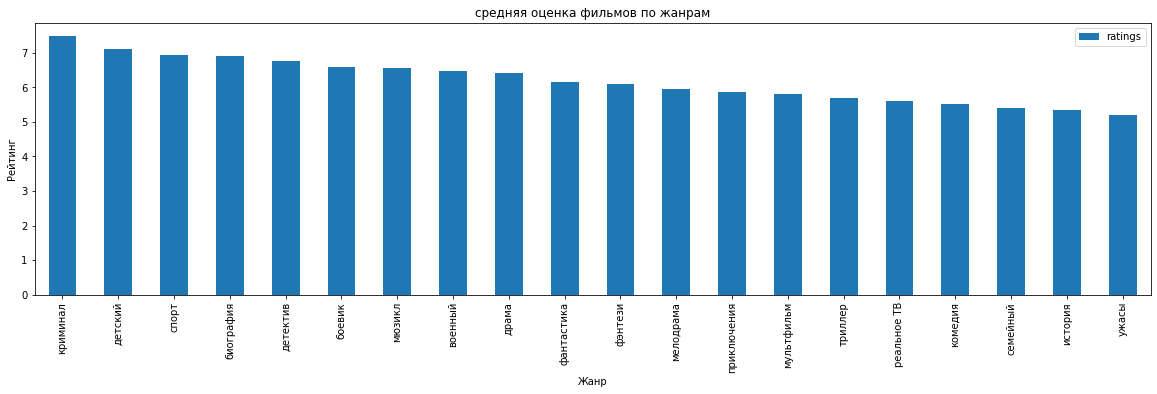

316

In [ ]:
#Сгруппируем данные по жанрам и выведем на график и средний рейтинг в порядке убывания.
data_supported_sorted[['main_genre', 'ratings']].groupby('main_genre').agg('mean').sort_values(by='ratings', ascending=False).plot(title='средняя оценка фильмов по жанрам', kind='bar', figsize=(20,5))
plt.ylabel('Рейтинг')
plt.xlabel('Жанр')
plt.show()
len(data_supported_sorted[['main_genre', 'ratings']])

In [ ]:
data_supported['ratings'].mean()

6.020886075949368

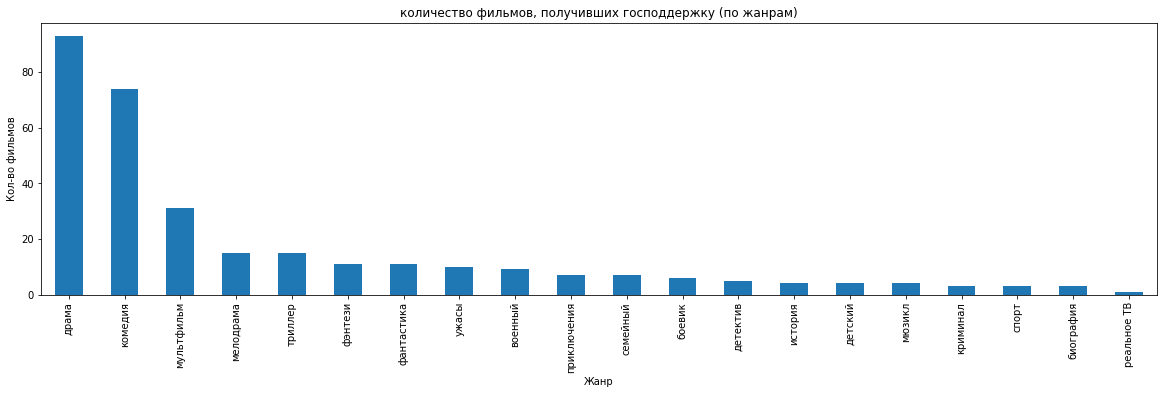

In [ ]:
#Тот же график построим для уникальных значений
data_supported_sorted['main_genre'].value_counts().plot(title='количество фильмов, получивших господдержку (по жанрам)', kind='bar', figsize=(20,5));
plt.ylabel('Кол-во фильмов')
plt.xlabel('Жанр')
plt.show()

Вывод:
1) Фильмы с жанром "драма" имеют наивысщий показатель государственной поддержки среди 29 жанров представленный на графике, количество таких фильмов 1688, при это рейтинги этих фильмов, находятся в топе, но не являются лучшими.
2) В топе рейтинга находятся такие жанры, как криминальный детектив, анимэ и музыка. Интересно то, что фильмы с этими жанрами имеют минимальную государственную подержку.

In [ ]:
data_supported['profit'] = data['box_office'] - data['budget']

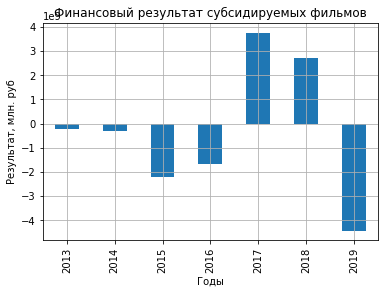

In [ ]:
#Создадим стобец с окупными фильмами, имеющими гос поддержку, чьи кассовые сборы были выше, чем бюджет и построим график
data_supported.groupby('year_info')['profit'].sum().plot(kind='bar', grid=True)
plt.title('Финансовый результат субсидируемых фильмов')
plt.xlabel('Годы')
plt.ylabel('Результат, млн. руб');

In [ ]:
temp1, temp2 = data_supported.box_office.sum(), data[data['refundable_support'].notna() | 
                                      data['nonrefundable_support'].notna()].box_office.sum()
print(temp1, temp2, round((temp2-temp1)/temp2*100, 2))
temp1, temp2 = data_supported.budget.sum(), data[data['refundable_support'].notna() | 
                                      data['nonrefundable_support'].notna()].budget.sum()
print(temp1, temp2, round((temp2-temp1)/temp2*100, 2))

42113509574.78 42113509574.78 0.0
44507178259.30408 44507178259.30408 0.0


Вывод:
1) Наивысшие показатели окупаемост показали 2017 и 2018 год, в эти годы кассовые сборы фильмов превысили бюджет кинокартин.
2) 2015, 2016, 2019 года являются убыточными для киностудий и министерства культуры, в эти годы профит отрицательный.

332

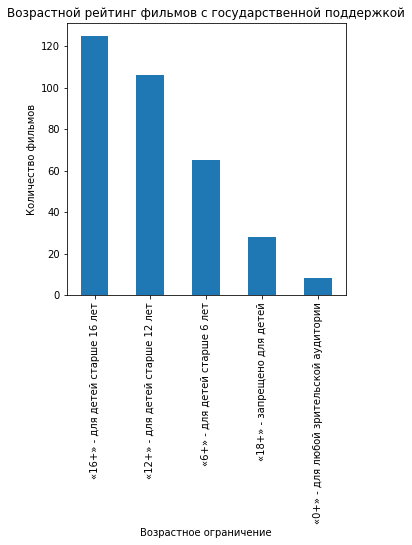

In [ ]:
data_supported['age_restriction'].value_counts().plot(y='count', kind='bar', figsize=(5, 5))
plt.ylabel('Количество фильмов')
plt.xlabel('Возрастное ограничение')
plt.title('Возрастной рейтинг фильмов с государственной поддержкой');  
len(data_supported['age_restriction'])

In [ ]:
data_supported_sorted['profit'] = data['box_office'] - data['budget']

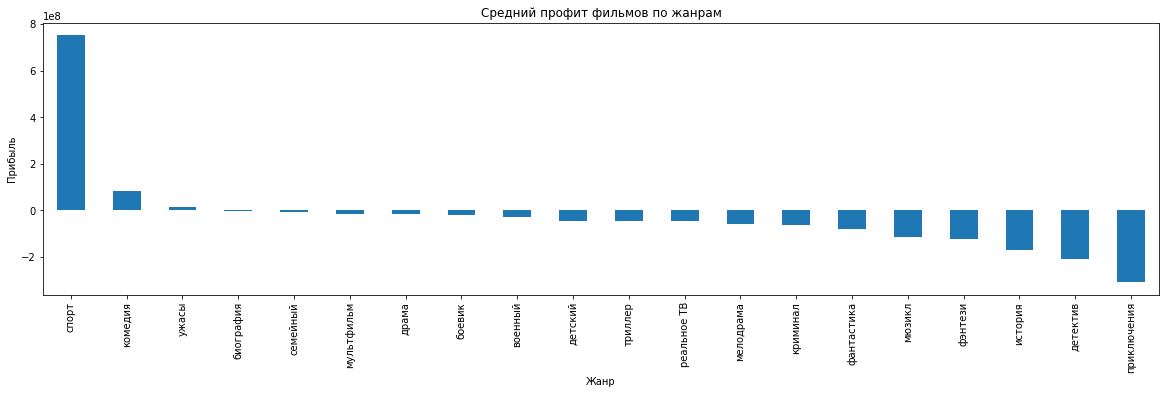

332

In [ ]:
#Посчитаем луший средний показатель по профиту среди жанров
data_supported_sorted.groupby('main_genre')['profit'].agg('mean').sort_values(ascending=False).plot(title='Средний профит фильмов по жанрам', kind='bar', figsize=(20,5));
plt.ylabel('Прибыль')
plt.xlabel('Жанр')
plt.show()
len(data_supported['profit'])

In [ ]:
data_supported_sorted.pivot_table(index= 'main_genre', values = ['total_support']).sort_values(by='total_support',ascending=False)

             total_support
main_genre                
история     255,000,000.00
спорт       151,666,666.67
фантастика  127,818,181.82
приключения  99,428,571.43
детектив     97,000,000.00
фэнтези      93,900,000.00
криминал     93,333,333.33
мультфильм   79,403,870.97
мюзикл       60,113,279.75
драма        57,144,157.33
боевик       55,666,666.67
реальное ТВ  53,000,000.00
триллер      51,309,685.67
семейный     48,428,571.43
военный      46,888,985.11
комедия      43,490,310.07
биография    37,503,333.33
ужасы        35,500,000.00
детский      29,750,000.00
мелодрама    26,533,333.33

Вывод:
1) Среди фильмов, получившим гос поддержку, самым окупаемым жанром является "спорт", показатели этого жанра имеют результат, предосходящий остальные в разы!
2) А вот жанр "реалити", хоть и имеют наивысщую поддержку государства, показывают худший результат по профиту.

Общий вывод по разделу: 
    После проведения исследовательского анализа данных фильмов с гос. поддержкой мы выявили:
       1. Самым популярным жанром является "криминальный детектив"- 7,5; самый непопулярный "ужасы"- 5,5
       2. Средний рейтинг таких фильмов составляет 6%
       3. Жанр, чаще всех получающий гос. поддержку- "драма", в то время как "реалити" меньше всего.
       4. Лучший финансовый результат был продемонстрирован в 2018 году, худший в 2019 году
       5. Самая популярная категория- 16+, не популярная- 0+
       6. Самые окупаемые фильмы в категории "спорт", в то время как "приключения" имеют отрицательную окупаемость.
       7. Самая высокая общая поодержка принадлежит жанру "история", а вот поддержка жанра "мелодрама" самая низкая, меньше "истории" почти в 10 раз

# Общий вывод

Мы обработали полученный архив данных из 23699 записей, заполнили пропущенные значения, избавились от ненужных данных, заменили типы колонок, там где это необходимо, проанализировали количественные и категориальные данные.
-Провели исследовательский анализ данных, где выяснили, что:
1) Доля фильмов, поступишвих в прокат составляет 42 процента.
2) Из года в год растет показатель фильмов, показанных в кинотеатре и соответственно их доля и исходя из этих данных количество прокатных уддостоверений будет только расти.
3) Фильмы категорий 6+, 12+, 16+ имеют большие шансы заработать в прокате
-Среди фильмов, получивших гос поддержку (всего 332):
1. Самым популярным жанром является "криминальный детектив"- 7,5; самый непопулярный "ужасы"- 5,5
2. Средний рейтинг таких фильмов составляет 6%
3. Жанр, чаще всех получающий гос. поддержку- "драма", в то время как "реалити" меньше всего.
4. Лучший финансовый результат был продемонстрирован в 2018 году, худший в 2019 году
5. Самая популярная категория- 16+, не популярная- 0+
6. Самые окупаемые фильмы в категории "спорт", в то время как "приключения" имеют отрицательную окупаемость.